In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('images/ISM/ISM_FWHM.csv')
display(data.head())

D0 = data['D0'].values
ISM_D1 = data['ISM D1'].values
ISM_D3 = data['ISM D3'].values
ISM_D5 = data['ISM D5'].values
ISM_D7 = data['ISM D7'].values
CONF_D1 = data['CONFOCALE D1'].values
CONF_D3 = data['CONFOCALE D3'].values
CONF_D5 = data['CONFOCALE D5'].values
CONF_D7 = data['CONFOCALE D7'].values

err_ISM_D1 = data['err ISM D1'].values
err_ISM_D3 = data['err ISM D3'].values
err_ISM_D5 = data['err ISM D5'].values
err_ISM_D7 = data['err ISM D7'].values
err_CONF_D1 = data['err CONFOCALE D1'].values
err_CONF_D3 = data['err CONFOCALE D3'].values
err_CONF_D5 = data['err CONFOCALE D5'].values
err_CONF_D7 = data['err CONFOCALE D7'].values

G1 = CONF_D1 / ISM_D1
G3 = CONF_D3 / ISM_D3
G5 = CONF_D5 / ISM_D5
G7 = CONF_D7 / ISM_D7

err_G1 = G1 * np.sqrt((err_CONF_D1 / CONF_D1) ** 2 + (err_ISM_D1 / ISM_D1) ** 2)
err_G3 = G3 * np.sqrt((err_CONF_D3 / CONF_D3) ** 2 + (err_ISM_D3 / ISM_D3) ** 2)
err_G5 = G5 * np.sqrt((err_CONF_D5 / CONF_D5) ** 2 + (err_ISM_D5 / ISM_D5) ** 2)
err_G7 = G7 * np.sqrt((err_CONF_D7 / CONF_D7) ** 2 + (err_ISM_D7 / ISM_D7) ** 2)

,FILE,D0,ISM D1,ISM D3,ISM D5,ISM D7,CONFOCALE D1,CONFOCALE D3,CONFOCALE D5,CONFOCALE D7,...,err CONFOCALE D7,ROI D0,ROI ISM D1,ROI ISM D3,ROI ISM D5,ROI ISM D7,ROI CONFOCALE D1,ROI CONFOCALE D3,ROI CONFOCALE D5,ROI CONFOCALE D7
0,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,266.0,270.0,280.0,313.0,323.0,345.0,379.0,387.0,396.0,...,3.0,0,0,0,0,0,0,0,0,0
1,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,272.0,265.0,271.0,305.0,313.0,344.0,379.0,390.0,396.0,...,5.0,1,1,2,1,1,1,1,1,1
2,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,273.0,260.0,262.0,295.0,306.0,341.0,375.0,386.0,397.0,...,6.0,2,2,1,2,2,2,2,2,2
3,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,260.0,254.0,261.0,296.0,311.0,339.0,372.0,386.0,398.0,...,7.0,3,4,3,3,3,3,3,3,3
4,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,246.0,237.0,243.0,271.0,280.0,308.0,335.0,348.0,353.0,...,20.0,4,3,4,4,4,4,4,4,4


In [3]:
def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values - average)**2, weights=weights)
    return np.sqrt(variance)

print("G1 weighted mean: {} ± {}".format(
    np.round(np.average(G1, weights=1/err_G1**2), 2), np.round(weighted_std(G1, 1/err_G1**2), 2)))
print("G3 weighted mean: {} ± {}".format(
    np.round(np.average(G3, weights=1/err_G3**2), 2), np.round(weighted_std(G3, 1/err_G3**2), 2)))
print("G5 weighted mean: {} ± {}".format(
    np.round(np.average(G5, weights=1/err_G5**2), 2), np.round(weighted_std(G5, 1/err_G5**2), 2)))
print("G7 weighted mean: {} ± {}".format(
    np.round(np.average(G7, weights=1/err_G7**2), 2), np.round(weighted_std(G7, 1/err_G7**2), 2)))

G1 weighted mean: 1.28 ± 0.03
G3 weighted mean: 1.35 ± 0.07
G5 weighted mean: 1.24 ± 0.06
G7 weighted mean: 1.23 ± 0.05


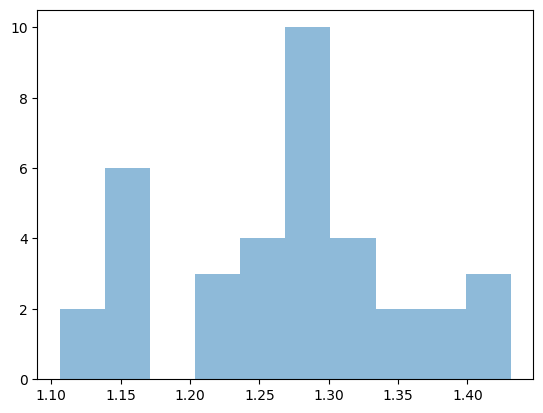

In [4]:
# plt.hist(G1, bins=6, alpha=0.5, label='D1')
# plt.hist(G3, bins=6, alpha=0.5, label='D3')
# plt.hist(G5, bins=6, alpha=0.5, label='D5')
# plt.hist(G7, bins=6, alpha=0.5, label='D7')
# plt.show()

plt.hist(np.concatenate((G1, G3, G5, G7)), bins=10, alpha=0.5, label='All data')
plt.show()

In [5]:
NA = 1.1
λ_laser = 770 # nm
r_airy = 0.61 * λ_laser / NA
print('R(airy):',np.round(r_airy), 'nm')

print(ISM_D1/r_airy)
print(ISM_D3/r_airy)
print(ISM_D5/r_airy)
print(ISM_D7/r_airy)

print(CONF_D1/r_airy)
print(CONF_D3/r_airy)
print(CONF_D5/r_airy)
print(CONF_D7/r_airy)

R(airy): 427.0 nm
[0.6323185  0.6206089  0.6088993  0.59484778 0.55503513 0.58079625
 0.54098361 0.51990632 0.68852459]
[0.6557377  0.63466042 0.61358314 0.61124122 0.56908665 0.59484778
 0.57845433 0.56440281 0.72599532]
[0.73302108 0.71428571 0.69086651 0.69320843 0.63466042 0.64168618
 0.6088993  0.61358314 0.76346604]
[0.75644028 0.73302108 0.71662763 0.72833724 0.6557377  0.65807963
 0.6323185  0.6323185  0.79391101]
[0.80796253 0.80562061 0.79859485 0.79391101 0.72131148 0.76346604
 0.66510539 0.66042155 0.79391101]
[0.88758782 0.88758782 0.87822014 0.87119438 0.78454333 0.83840749
 0.71194379 0.70725995 0.8501171 ]
[0.90632319 0.91334895 0.90398126 0.90398126 0.81498829 0.83372365
 0.70491803 0.71194379 0.84777518]
[0.92740047 0.92740047 0.92974239 0.93208431 0.82669789 0.84777518
 0.72833724 0.72599532 0.87822014]


In [6]:
ISM_D1_mean = np.mean(ISM_D1)
ISM_D3_mean = np.mean(ISM_D3)
ISM_D5_mean = np.mean(ISM_D5)
ISM_D7_mean = np.mean(ISM_D7)

print("ISM D1 mean:", np.round(ISM_D1_mean))
print("ISM D3 mean:", np.round(ISM_D3_mean))
print("ISM D5 mean:", np.round(ISM_D5_mean))
print("ISM D7 mean:", np.round(ISM_D7_mean))

ISM D1 mean: 253.0
ISM D3 mean: 263.0
ISM D5 mean: 289.0
ISM D7 mean: 299.0


In [7]:
print('D0: ', D0.astype(int))
print('ISM D1: ',ISM_D1.astype(int))
print('ISM D3: ',ISM_D3.astype(int))
print('ISM D5: ',ISM_D5.astype(int))
print('ISM D7: ',ISM_D7.astype(int))
print('CONF D1: ',CONF_D1.astype(int))
print('CONF D3: ',CONF_D3.astype(int))
print('CONF D5: ',CONF_D5.astype(int))
print('CONF D7: ',CONF_D7.astype(int))

D0:  [266 272 273 260 246 241 227 217 278]
ISM D1:  [270 265 260 254 237 248 231 222 294]
ISM D3:  [280 271 262 261 243 254 247 241 310]
ISM D5:  [313 305 295 296 271 274 260 262 326]
ISM D7:  [323 313 306 311 280 281 270 270 339]
CONF D1:  [345 344 341 339 308 326 284 282 339]
CONF D3:  [379 379 375 372 335 358 304 302 363]
CONF D5:  [387 390 386 386 348 356 301 304 362]
CONF D7:  [396 396 397 398 353 362 311 310 375]


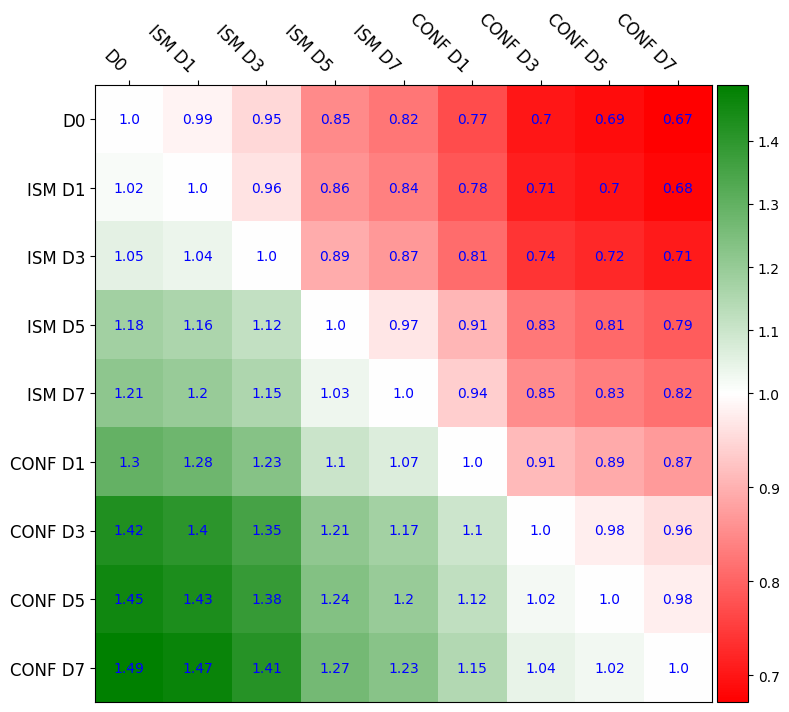

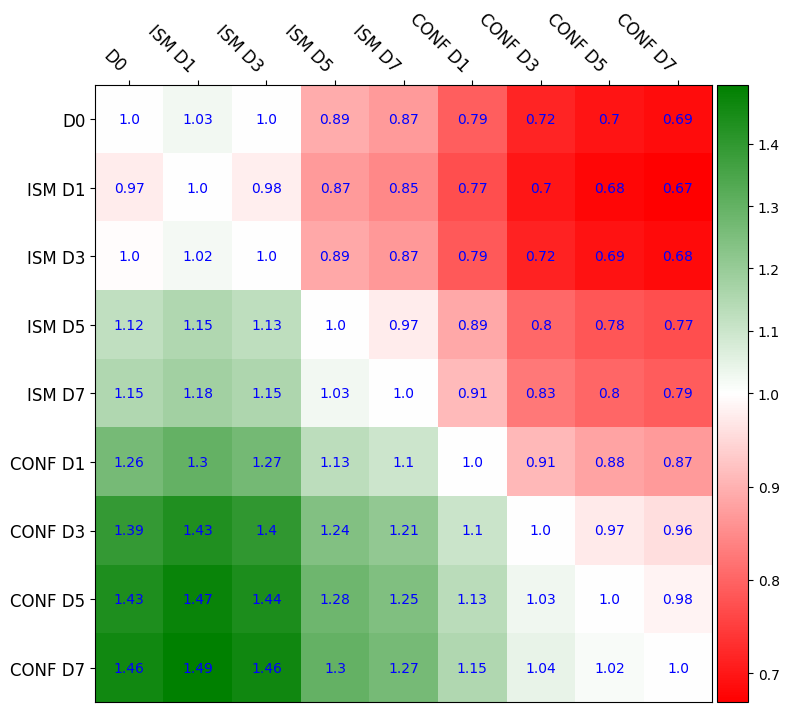

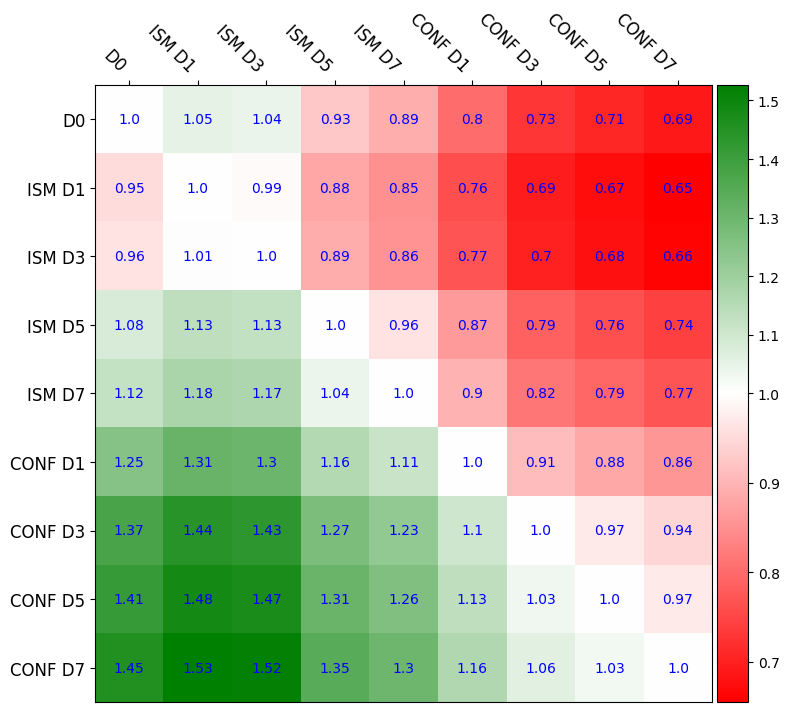

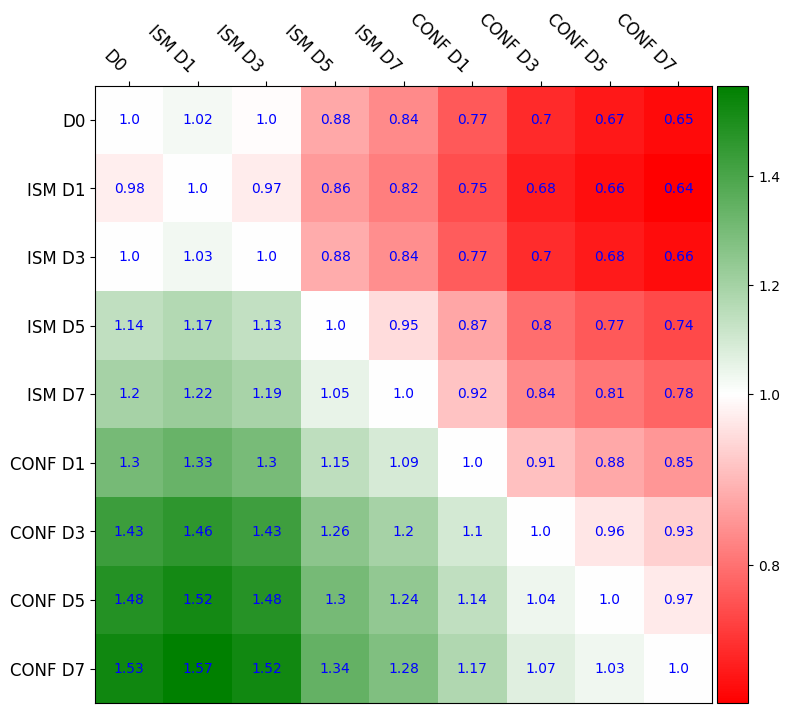

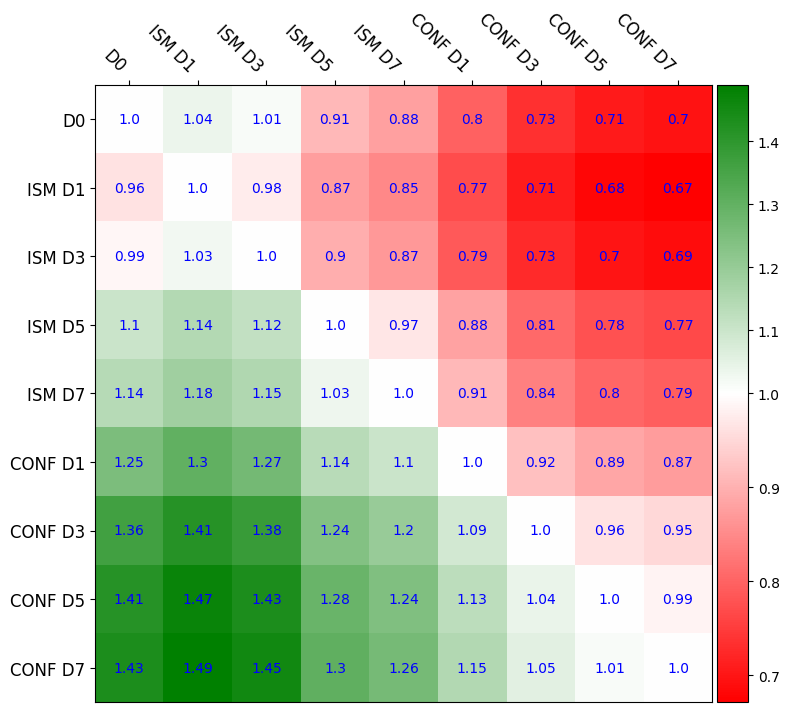

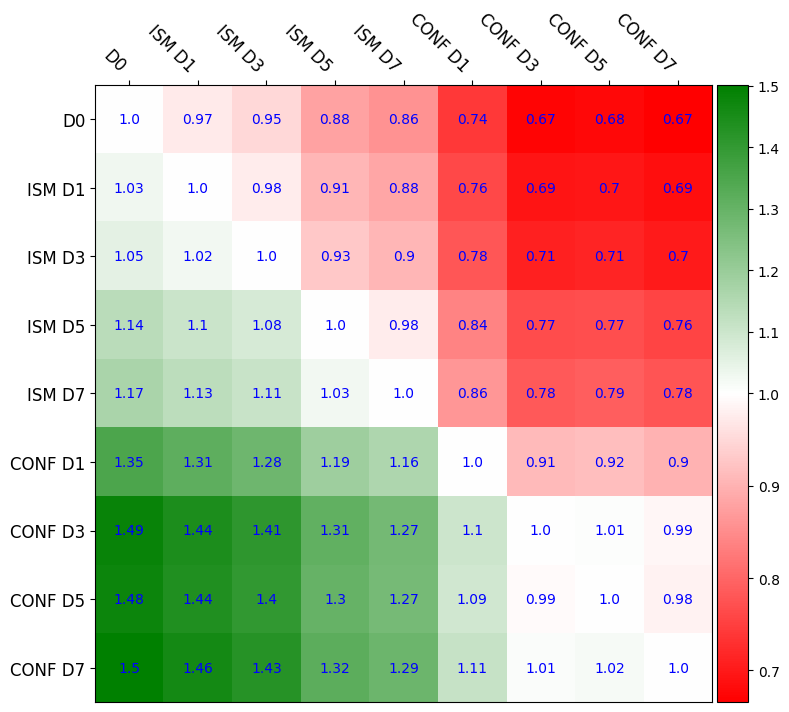

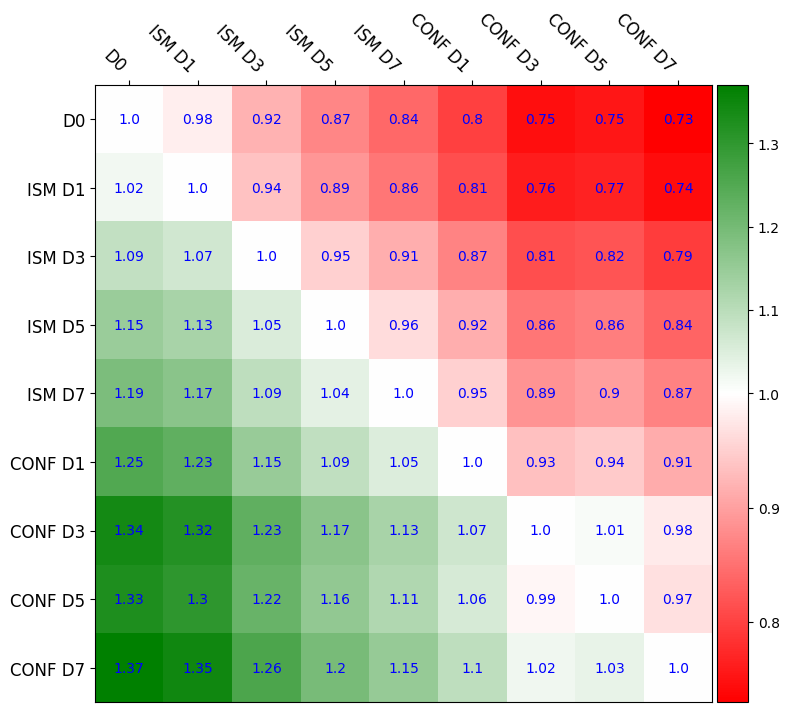

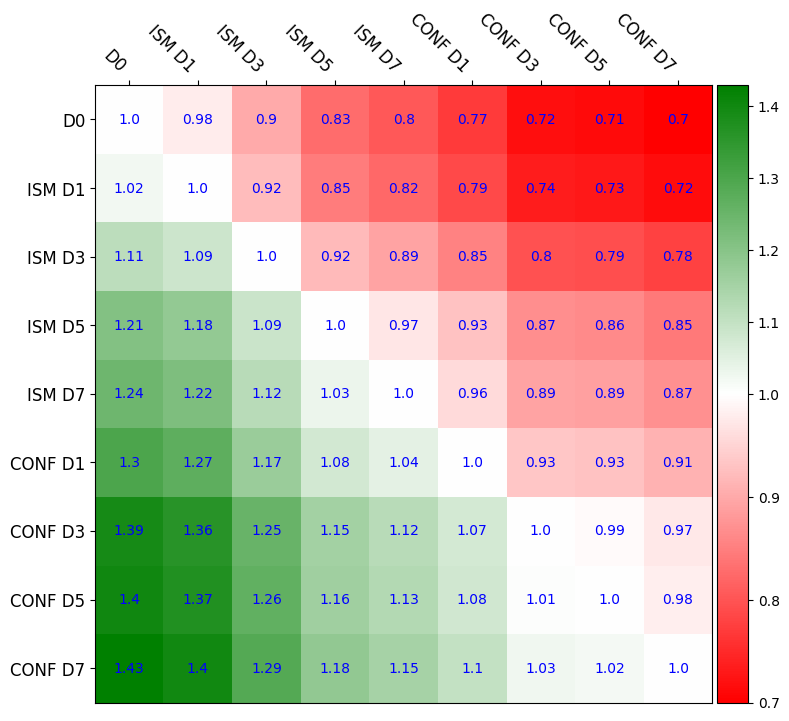

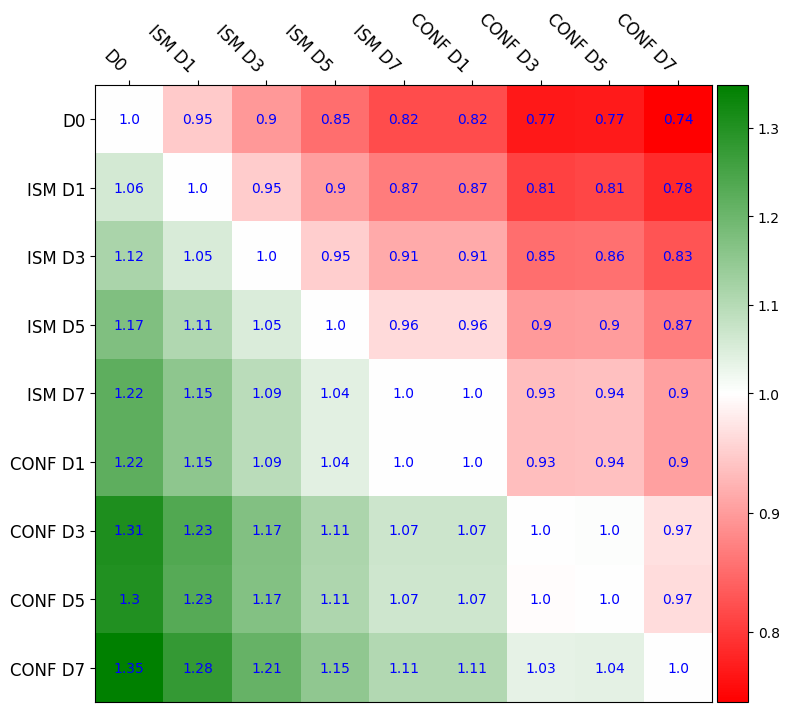

(9, 9, 9)


In [13]:
data = np.array([D0, ISM_D1, ISM_D3, ISM_D5, ISM_D7, CONF_D1, CONF_D3, CONF_D5, CONF_D7]).T
labels = ['D0', 'ISM D1', 'ISM D3', 'ISM D5', 'ISM D7', 'CONF D1', 'CONF D3', 'CONF D5', 'CONF D7']

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

matrici = []
matrix = np.zeros((9,9))
for row in data:
    for i, e1 in enumerate(row):
        for j, e2 in enumerate(row):
            matrix[i,j] = e1/e2
    matrici.append(matrix)
    cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
    norm = TwoSlopeNorm(vmin=matrix.min(), vcenter=1.0, vmax=matrix.max())
    # plt.imshow(matrix, cmap='viridis', vmin=0, vmax=2)
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(matrix,  cmap=cmap, norm=norm)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)

    # Set axis labels and ticks
    ax.set_xticks(np.arange(len(labels)))
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=-45, ha='right', fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)
    #ax.set_xlabel('Compared', fontsize=14)
    #ax.set_ylabel('Reference', fontsize=14)

    # Annotate values
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{np.round(matrix[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)
    cbar.remove()  # remove the previous colorbar
    plt.tight_layout()
    plt.show()

matrici = np.array(matrici)
print(matrici.shape)



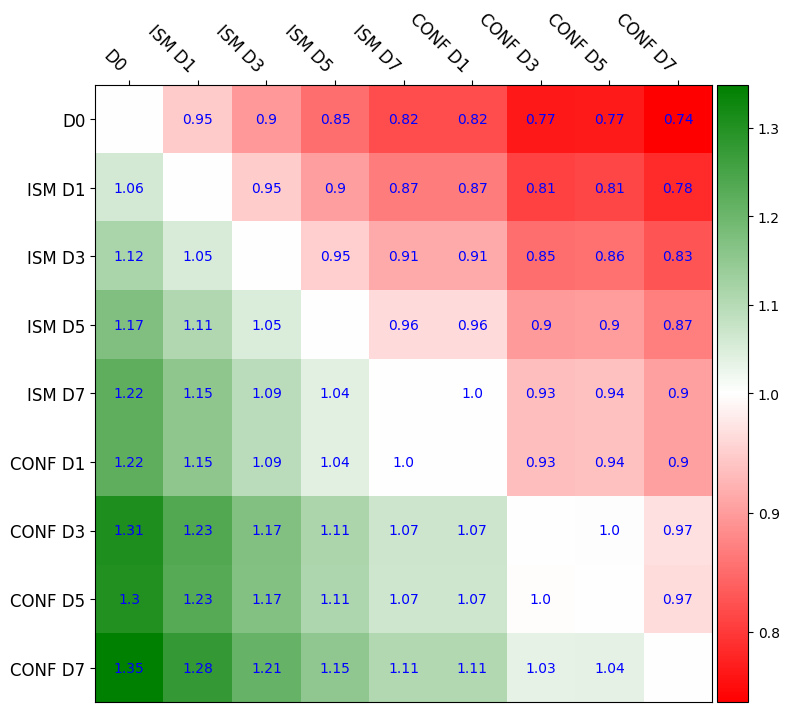

In [24]:
matrix = np.mean(matrici, axis=0)
# print(matrix)

cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
# norm = TwoSlopeNorm(vmin=matrix.min(), vcenter=1.0, vmax=matrix.max())
# plt.imshow(matrix, cmap='viridis', vmin=0, vmax=2)
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(matrix,  cmap=cmap, norm=norm)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)

# Set axis labels and ticks
ax.set_xticks(np.arange(len(labels)))
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=-45, ha='right', fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
#ax.set_xlabel('Compared', fontsize=14)
#ax.set_ylabel('Reference', fontsize=14)

# Annotate values
for i in range(len(labels)):
    for j in range(len(labels)):
        if i == j: continue
        ax.text(j, i, f"{np.round(matrix[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax)
cbar.remove()  # remove the previous colorbar
plt.tight_layout()
plt.show()

(9, 4, 4)


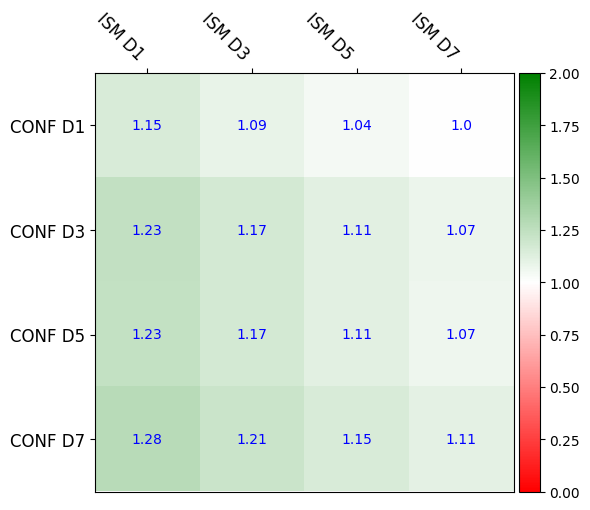

In [33]:

labelx = np.array(['ISM D1', 'ISM D3', 'ISM D5', 'ISM D7'])
labely = np.array(['CONF D1', 'CONF D3', 'CONF D5', 'CONF D7'])

ISM_DATA = np.array([ISM_D1, ISM_D3, ISM_D5, ISM_D7]).T
CONF_DATA = np.array([CONF_D1, CONF_D3, CONF_D5, CONF_D7]).T

tante_matricione = []
matricina = np.zeros((4,4))
for ism,conf in zip(ISM_DATA, CONF_DATA):
    for i, e1 in enumerate(ism):
        for j, e2 in enumerate(conf):
            matricina[j,i] = e2/e1
    tante_matricione.append(matricina)
tante_matricione = np.array(tante_matricione)
print(tante_matricione.shape)

    
matrix_guadagno = np.mean(tante_matricione, axis=0)

cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
try:
    norm = TwoSlopeNorm(vmin=matrix_guadagno.min(), vcenter=1.0, vmax=matrix_guadagno.max())
except:
    norm = TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=2)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrix_guadagno,  cmap=cmap, norm=norm)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Ratio', fontsize=14)

# Set axis labels and ticks


ax.set_xticks(np.arange(4))
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(np.arange(4))
ax.set_xticklabels(labelx, rotation=-45, ha='right', fontsize=12)
ax.set_yticklabels(labely, fontsize=12)
#ax.set_xlabel('Compared', fontsize=14)
#ax.set_ylabel('Reference', fontsize=14)

# Annotate values
for i in range(len(labely)):
    for j in range(len(labelx)):
        ax.text(j, i, f"{np.round(matrix_guadagno[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax)
cbar.remove()  # remove the previous colorbar
plt.tight_layout()
plt.show()